In [1]:
import pandas as pd
df = pd.read_csv('/content/European_Bank.csv')
df.head()


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:\n")
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Exited'].value_counts())


Shape: (10000, 14)

Columns:
 Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null

In [3]:
# remove useless columns
df = df.drop(['Year','CustomerId','Surname'], axis=1)

# convert categorical
df['HasCrCard'] = df['HasCrCard'].astype('category')
df['IsActiveMember'] = df['IsActiveMember'].astype('category')
df['Exited'] = df['Exited'].astype('category')

# encode gender
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Age groups
def age_group(age):
    if age < 30:
        return "<30"
    elif age <= 45:
        return "30-45"
    elif age <= 60:
        return "46-60"
    else:
        return "60+"

df['AgeGroup'] = df['Age'].apply(age_group)

# Credit score band
def credit_band(score):
    if score < 500:
        return "Low"
    elif score <= 700:
        return "Medium"
    else:
        return "High"

df['CreditBand'] = df['CreditScore'].apply(credit_band)

# Tenure group
def tenure_group(t):
    if t <= 3:
        return "New"
    elif t <= 7:
        return "Mid-term"
    else:
        return "Long-term"

df['TenureGroup'] = df['Tenure'].apply(tenure_group)

# Balance group
def balance_group(b):
    if b == 0:
        return "Zero Balance"
    elif b <= 100000:
        return "Low Balance"
    else:
        return "High Balance"

df['BalanceGroup'] = df['Balance'].apply(balance_group)

df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditBand,TenureGroup,BalanceGroup
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero Balance
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low Balance
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,30-45,Medium,Long-term,High Balance
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,30-45,Medium,New,Zero Balance
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High Balance


In [5]:
churn_rate = df['Exited'].value_counts(normalize=True)*100
print("Overall Churn %:\n", churn_rate)


Overall Churn %:
 Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [6]:
geo = pd.crosstab(df['Geography'], df['Exited'], normalize='index')*100
print("\nGeography Churn:\n", geo)



Geography Churn:
 Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


In [7]:
age = pd.crosstab(df['AgeGroup'], df['Exited'], normalize='index')*100
print("\nAge Churn:\n", age)



Age Churn:
 Exited            0          1
AgeGroup                      
30-45     84.699104  15.300896
46-60     48.876746  51.123254
60+       75.215517  24.784483
<30       92.443632   7.556368


In [8]:
credit = pd.crosstab(df['CreditBand'], df['Exited'], normalize='index')*100
print("\nCredit Score Churn:\n", credit)



Credit Score Churn:
 Exited              0          1
CreditBand                      
High        80.134788  19.865212
Low         76.265823  23.734177
Medium      79.718490  20.281510


In [9]:
tenure = pd.crosstab(df['TenureGroup'], df['Exited'], normalize='index')*100
print("\nTenure Churn:\n", tenure)



Tenure Churn:
 Exited               0          1
TenureGroup                      
Long-term    79.551821  20.448179
Mid-term     80.355355  19.644645
New          78.858773  21.141227


In [10]:
balance = pd.crosstab(df['BalanceGroup'], df['Exited'], normalize='index')*100
print("\nBalance Churn:\n", balance)



Balance Churn:
 Exited                0          1
BalanceGroup                      
High Balance  74.765576  25.234424
Low Balance   79.419192  20.580808
Zero Balance  86.176389  13.823611


In [11]:
high_value = df[df['BalanceGroup']=="High Balance"]
print("High Value Customer Churn:\n",
      high_value['Exited'].value_counts(normalize=True)*100)


High Value Customer Churn:
 Exited
0    74.765576
1    25.234424
Name: proportion, dtype: float64


In [12]:
gender = pd.crosstab(df['Gender'], df['Exited'], normalize='index')*100
print("Gender Churn:\n", gender)


Gender Churn:
 Exited          0          1
Gender                      
0       74.928461  25.071539
1       83.544072  16.455928


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


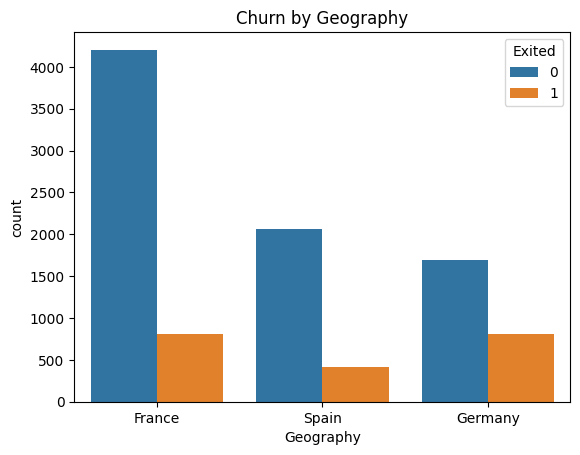

In [14]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Churn by Geography")
plt.show()


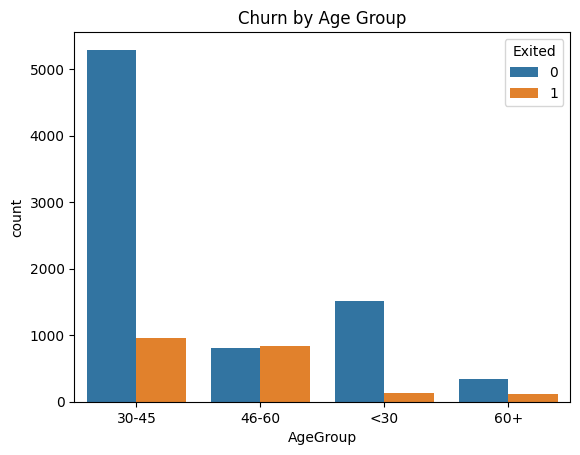

In [15]:
sns.countplot(x='AgeGroup', hue='Exited', data=df)
plt.title("Churn by Age Group")
plt.show()


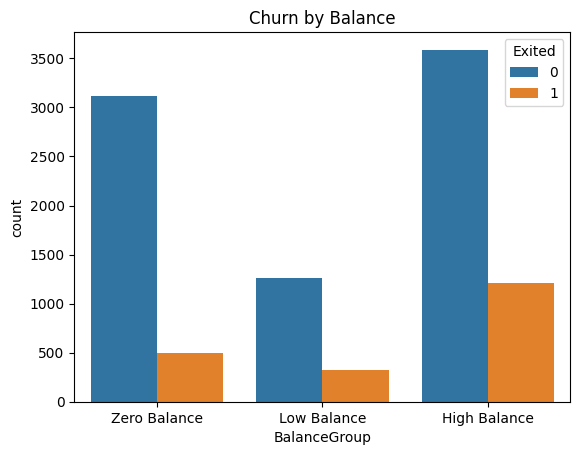

In [16]:
sns.countplot(x='BalanceGroup', hue='Exited', data=df)
plt.title("Churn by Balance")
plt.show()


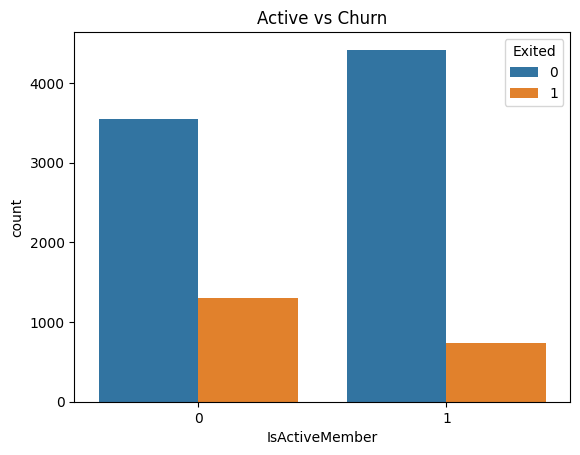

In [17]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title("Active vs Churn")
plt.show()
